# Boundary maps

The Municipal Demarcation Board (MDB) 2026 shapefiles give the ward and district boundaries.
This notebook shows how the project uses them.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

from quackathon.config import METRIC_CRS, MUNICIPALITY_CODE, PilotConfig
from quackathon.grid import load_grid
from quackathon.overture import fetch_building_centroids
from quackathon.region import load_ward, load_wards
from quackathon.screening import Municipality, screen_wards
from quackathon import viz

viz.use_style()
%config InlineBackend.figure_format = "retina"

cfg = PilotConfig(ward_no=4)

## 1. Source shapefiles

Districts and wards for South Africa, in EPSG:3857.

In [2]:
districts = gpd.read_file(cfg.shapefile_dir / "MDBDistrictMunicipalities2026" / "MDBDistrictMunicipalities2026.shp")
all_wards = gpd.read_file(cfg.shapefile_dir / "MDBWards2026" / "MDBWards2026.shp")
district_code = all_wards.loc[all_wards["CAT_B"] == MUNICIPALITY_CODE, "DISTRICTCO"].iloc[0]
print(f"{len(districts)} districts, {all_wards['CAT_B'].nunique()} local municipalities, {len(all_wards):,} wards")
print(f"{MUNICIPALITY_CODE} is in district {district_code}")

52 districts, 213 local municipalities, 4,485 wards
EC444 is in district DC44


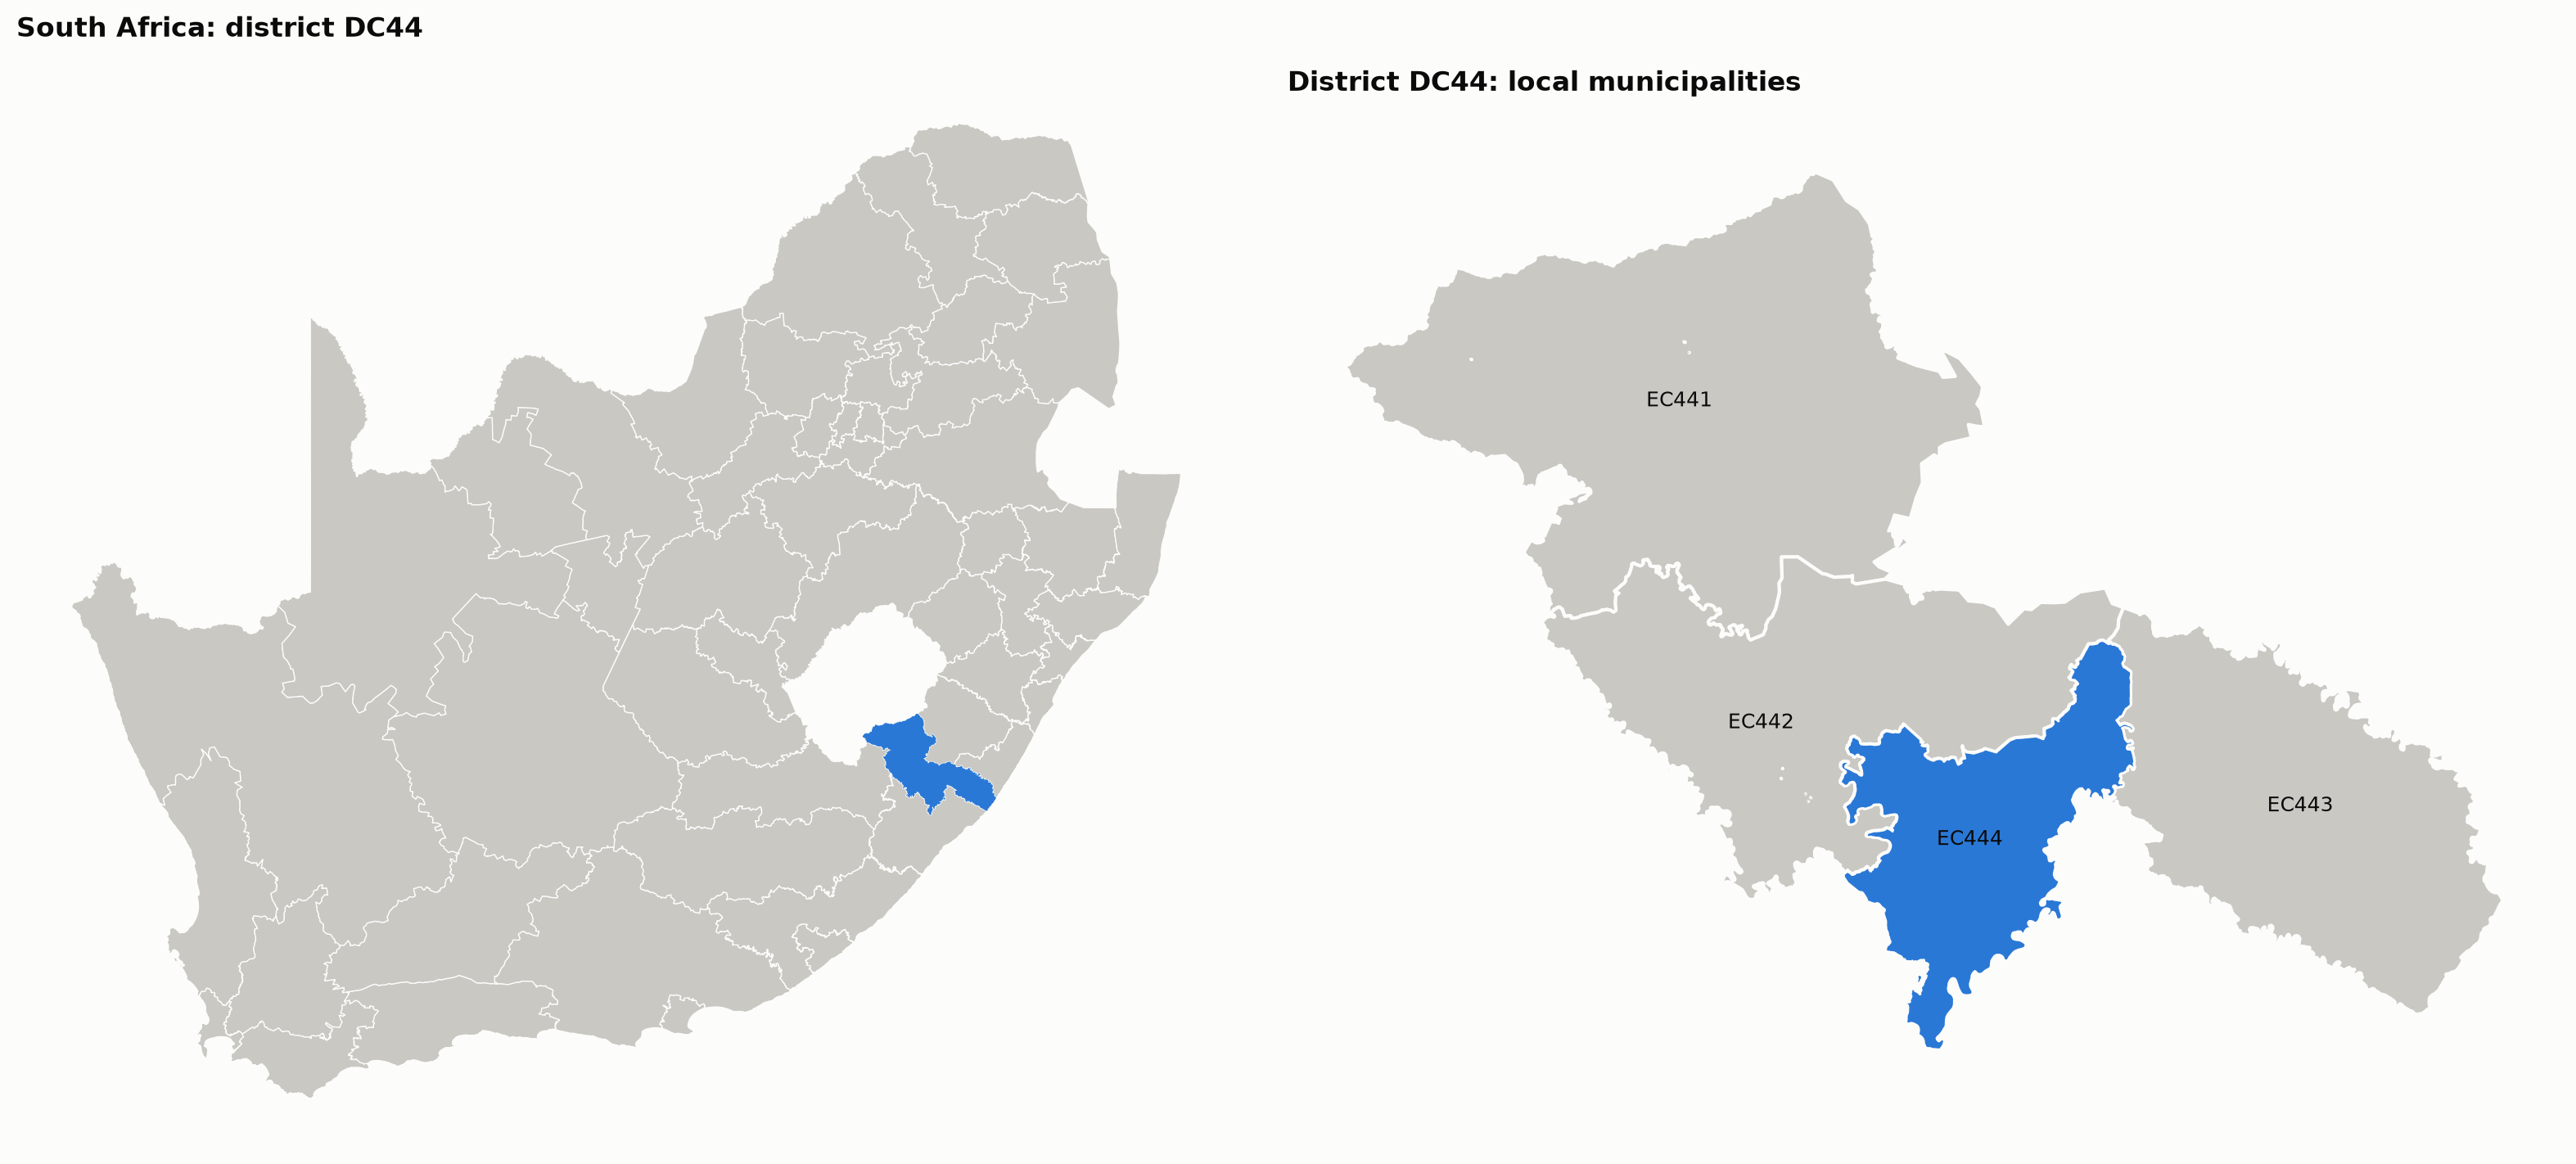

In [3]:
district = all_wards[all_wards["DISTRICTCO"] == district_code].dissolve("CAT_B").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
districts.plot(ax=axes[0], color=viz.CONTEXT, edgecolor=viz.SURFACE, linewidth=0.5)
districts[districts["DISTRICT"] == district_code].plot(ax=axes[0], color=viz.SERVED)
axes[0].set_aspect("equal"); axes[0].set_axis_off()
axes[0].set_title(f"South Africa: district {district_code}")

district.plot(ax=axes[1], color=viz.CONTEXT, edgecolor=viz.SURFACE, linewidth=1.5)
district[district["CAT_B"] == MUNICIPALITY_CODE].plot(ax=axes[1], color=viz.SERVED, edgecolor=viz.SURFACE)
for _, m in district.iterrows():
    p = m.geometry.representative_point()
    axes[1].annotate(m["CAT_B"], (p.x, p.y), ha="center", fontsize=9, color=viz.INK)
axes[1].set_aspect("equal"); axes[1].set_axis_off()
axes[1].set_title(f"District {district_code}: local municipalities")
plt.tight_layout()
plt.show()

## 2. Wards of the municipality

`load_wards` keeps the wards of EC444 and converts them to UTM zone 35S (EPSG:32735).
Distances are then in metres.

In [4]:
wards = load_wards(cfg)
print(f"{len(wards)} wards, CRS {wards.crs.to_string()}")
wards[["WardNo", "WardID", "MUNICNAME"]].assign(area_km2=wards.area / 1e6).set_index("WardNo").round(1)

19 wards, CRS EPSG:32735


,WardID,MUNICNAME,area_km2
WardNo,,,
1,24404001,Ntabankulu,92.9
2,24404002,Ntabankulu,63.2
3,24404003,Ntabankulu,57.9
4,24404004,Ntabankulu,100.9
5,24404005,Ntabankulu,82.9
6,24404006,Ntabankulu,26.0
7,24404007,Ntabankulu,92.9
8,24404008,Ntabankulu,69.1
9,24404009,Ntabankulu,116.5


## 3. Clip the data to a ward

The project uses each ward polygon to:
- download the buildings (bounding box of the municipality),
- keep the buildings inside the ward,
- keep the grid lines within 20 km of the ward.

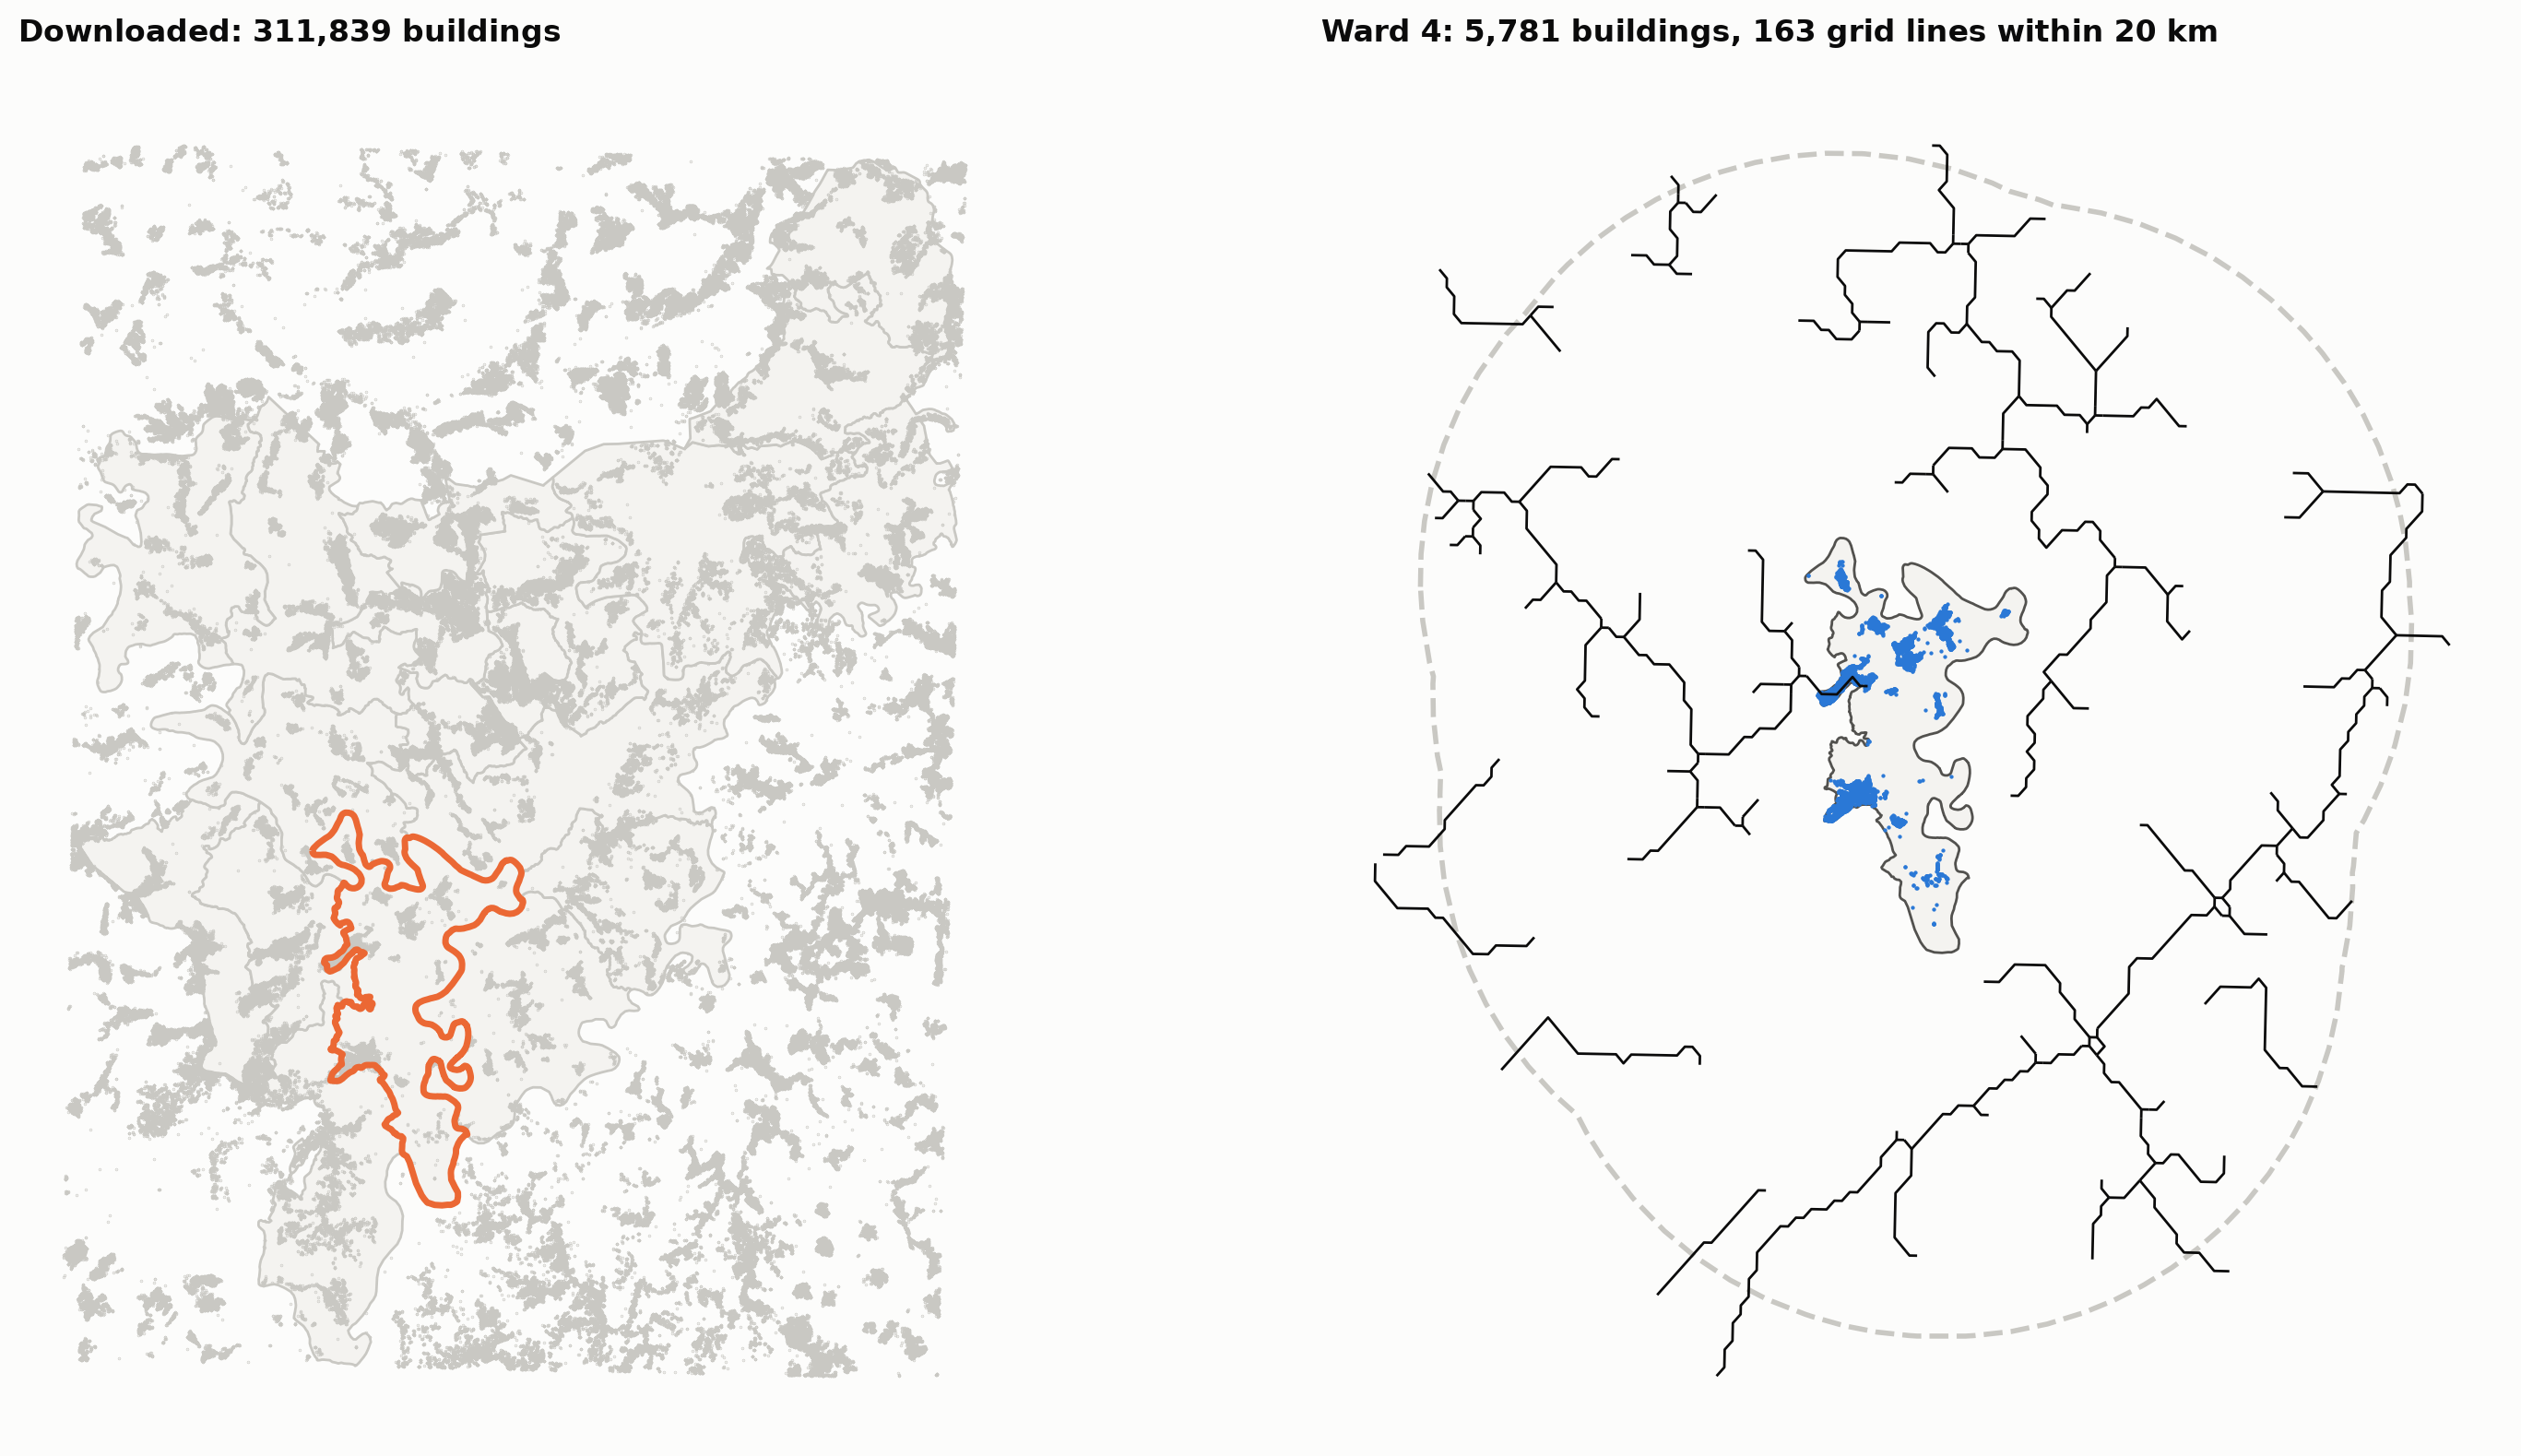

In [5]:
ward = load_ward(cfg)
buildings = fetch_building_centroids(wards, cfg.raw_dir)
in_ward = buildings[buildings.within(ward.union_all())]
grid = load_grid(ward, cfg)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
wards.plot(ax=axes[0], color="#f4f3f0", edgecolor=viz.CONTEXT)
buildings.plot(ax=axes[0], color=viz.CONTEXT, markersize=0.05)
ward.boundary.plot(ax=axes[0], color=viz.UNSERVED, linewidth=2.5)
axes[0].set_aspect("equal"); axes[0].set_axis_off()
axes[0].set_title(f"Downloaded: {len(buildings):,} buildings")

ward.buffer(20_000).boundary.plot(ax=axes[1], color=viz.CONTEXT, linestyle="--")
ward.plot(ax=axes[1], color="#f4f3f0", edgecolor=viz.INK_SECONDARY)
grid.plot(ax=axes[1], color=viz.INK, linewidth=1)
in_ward.plot(ax=axes[1], color=viz.SERVED, markersize=0.3)
axes[1].set_aspect("equal"); axes[1].set_axis_off()
axes[1].set_title(f"Ward {cfg.ward_no}: {len(in_ward):,} buildings, {len(grid)} grid lines within 20 km")
plt.tight_layout()
plt.show()

## 4. Results per ward

`Municipality.load` joins each building to its ward. Each ward result then maps to its polygon.

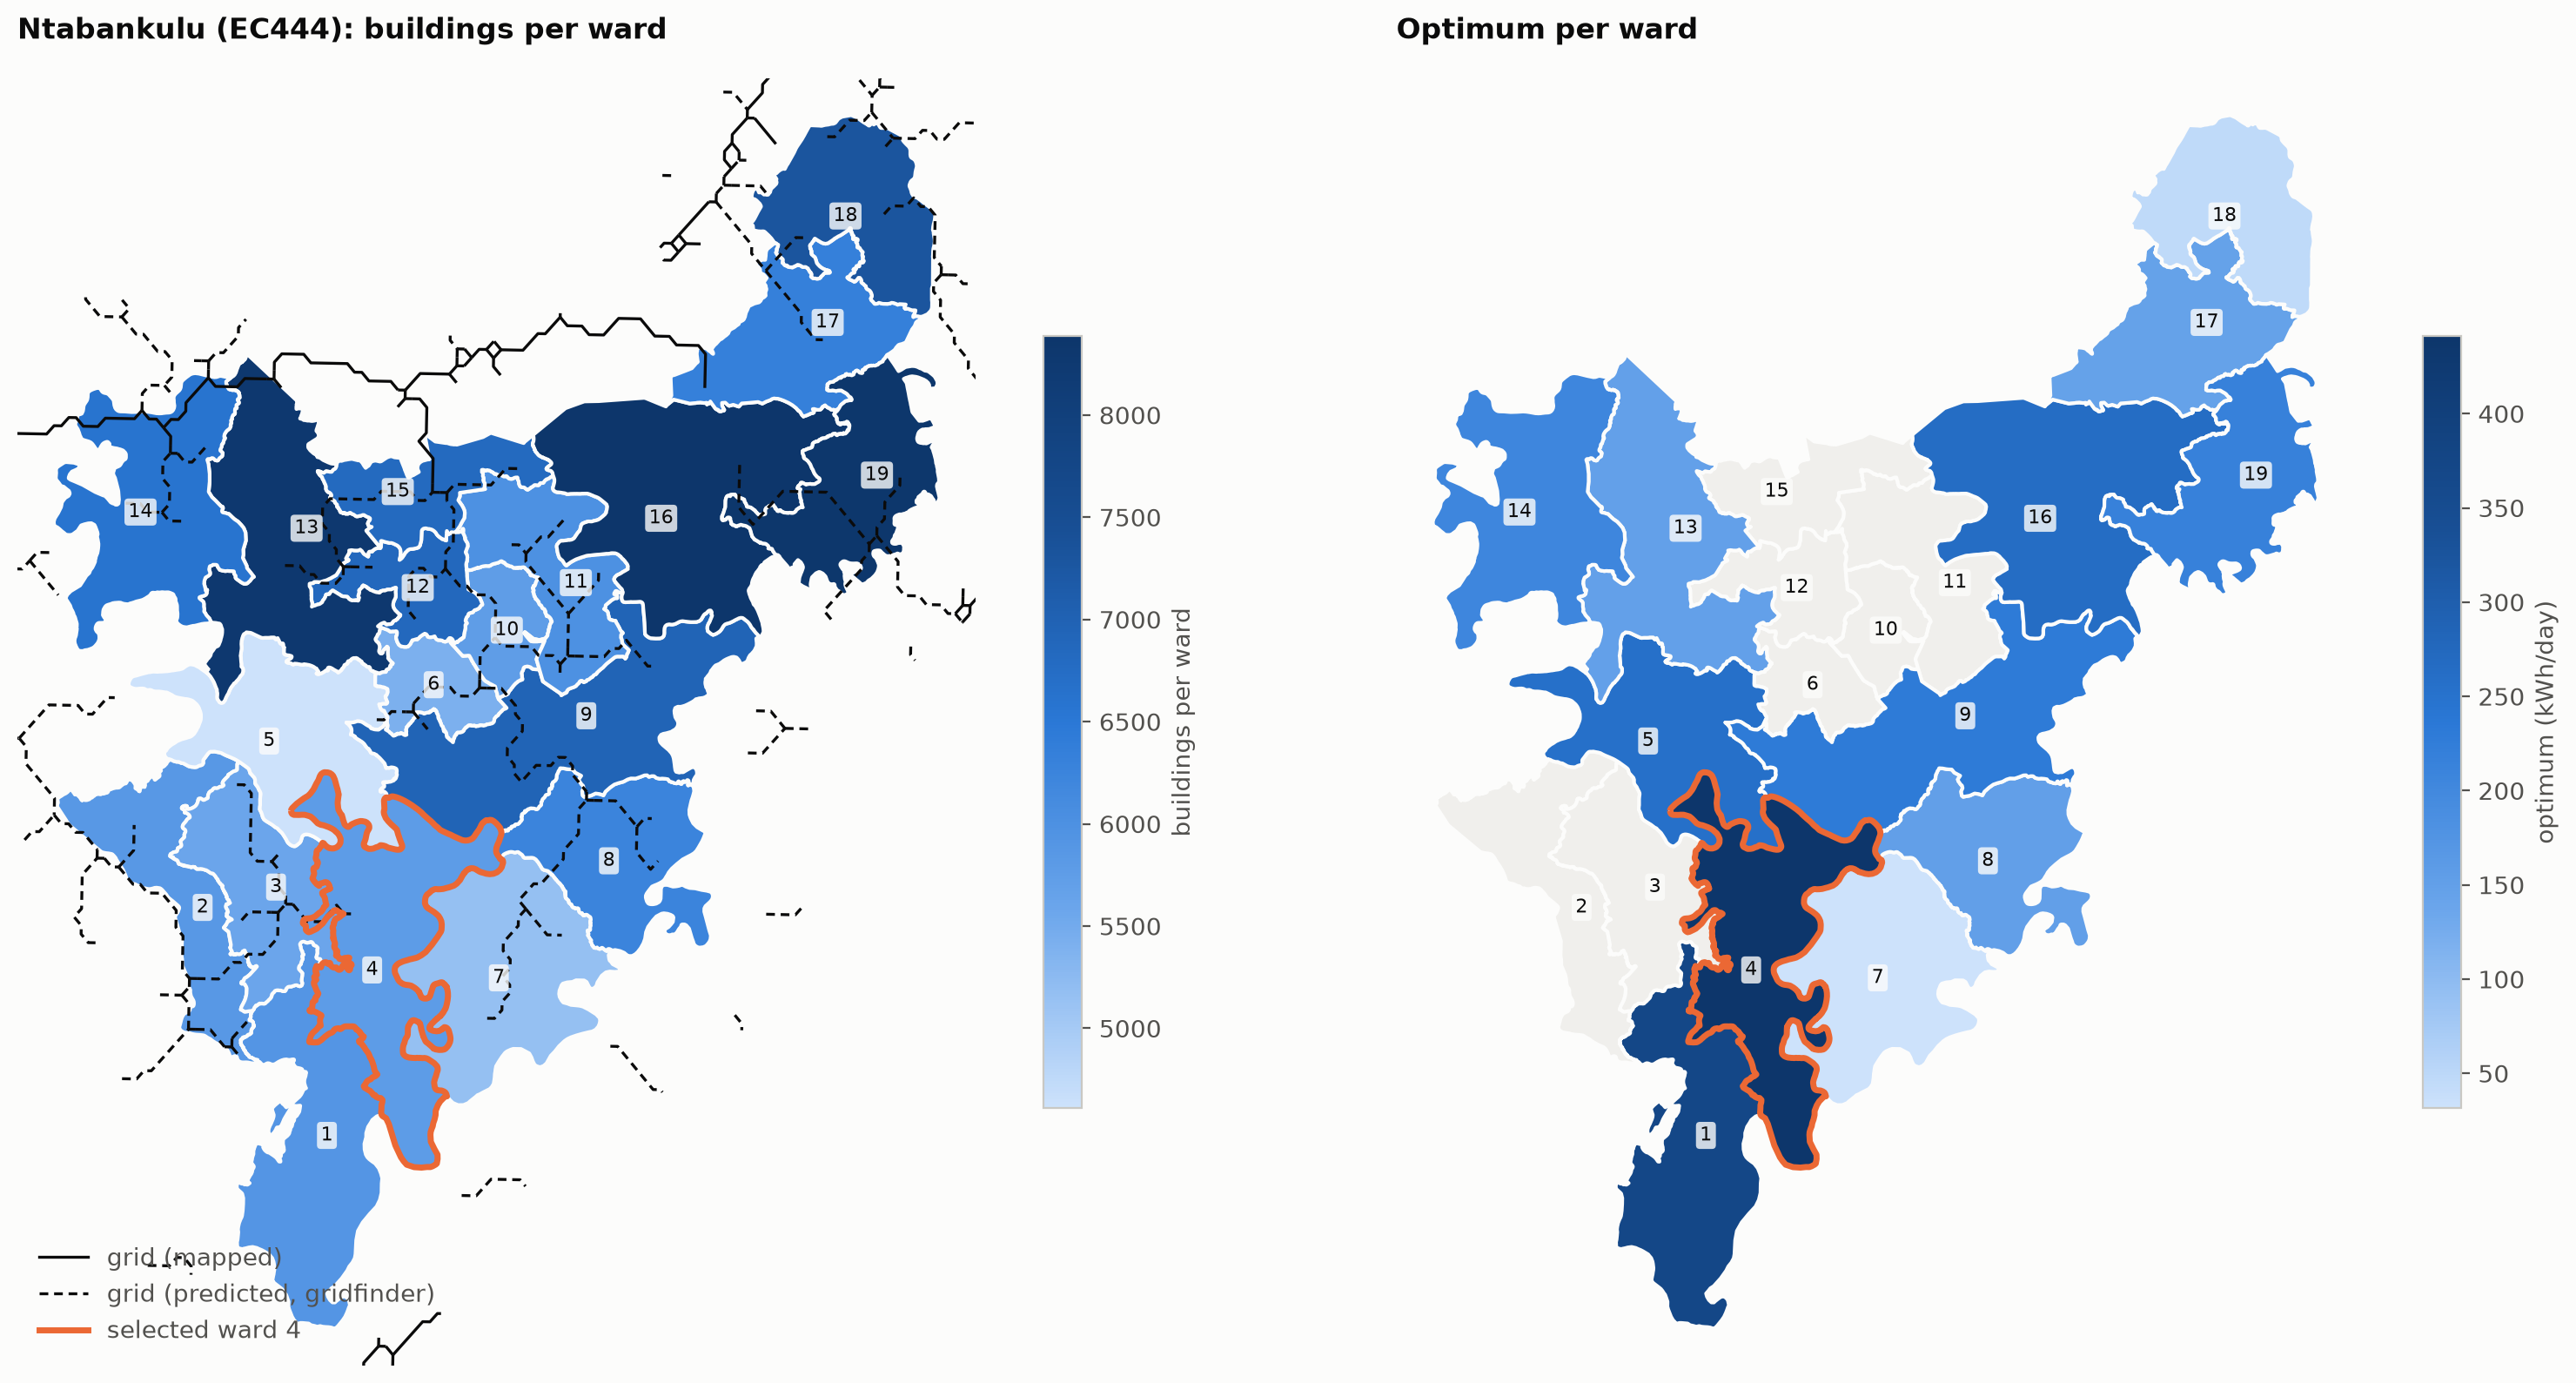

In [6]:
muni = Municipality.load(cfg)
screen = screen_wards(muni, cfg)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
viz.plot_municipality(wards, buildings, muni.grid, pilot_ward=cfg.ward_no, ax=axes[0])
viz.plot_ward_choropleth(wards, screen["served"], "optimum (kWh/day)", "Optimum per ward",
                         highlight=cfg.ward_no, ax=axes[1])
plt.tight_layout()
plt.show()